# Are Fandango's Movie Ratings Inflated?

In 2015, data journalist Walt Hickey published an investigation for FiveThirtyEight
claiming that Fandango's star ratings were systematically higher than the ratings
shown on other review sites — even for movies with genuinely poor reviews.

**Question:** Does the data support this claim?

**Data source:** [FiveThirtyEight's Fandango dataset](https://github.com/fivethirtyeight/data/tree/master/fandango)
- `fandango_score_comparison.csv` — 146 films with ratings from Fandango, Rotten Tomatoes,
  Metacritic, and IMDB, all on a common scale.
- `fandango_scrape.csv` — 510 films, showing Fandango's **displayed star rating** next to
  the **true rating value** hidden in the page's HTML.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

comparison = pd.read_csv("fandango_score_comparison.csv")
scrape = pd.read_csv("fandango_scrape.csv")

comparison.head()


,FILM,RottenTomatoes,RottenTomatoes_User,Metacritic,Metacritic_User,IMDB,Fandango_Stars,Fandango_Ratingvalue,RT_norm,RT_user_norm,...,IMDB_norm,RT_norm_round,RT_user_norm_round,Metacritic_norm_round,Metacritic_user_norm_round,IMDB_norm_round,Metacritic_user_vote_count,IMDB_user_vote_count,Fandango_votes,Fandango_Difference
0,Avengers: Age of Ultron (2015),74,86,66,7.1,7.8,5.0,4.5,3.70,4.3,...,3.90,3.5,4.5,3.5,3.5,4.0,1330,271107,14846,0.5
1,Cinderella (2015),85,80,67,7.5,7.1,5.0,4.5,4.25,4.0,...,3.55,4.5,4.0,3.5,4.0,3.5,249,65709,12640,0.5
2,Ant-Man (2015),80,90,64,8.1,7.8,5.0,4.5,4.00,4.5,...,3.90,4.0,4.5,3.0,4.0,4.0,627,103660,12055,0.5
3,Do You Believe? (2015),18,84,22,4.7,5.4,5.0,4.5,0.90,4.2,...,2.70,1.0,4.0,1.0,2.5,2.5,31,3136,1793,0.5
4,Hot Tub Time Machine 2 (2015),14,28,29,3.4,5.1,3.5,3.0,0.70,1.4,...,2.55,0.5,1.5,1.5,1.5,2.5,88,19560,1021,0.5


## Step 1: Understand the columns

The two files use different scales, so it's worth checking what each column actually
means before comparing anything.

- `comparison` has raw scores (0–100 for RT/Metacritic, 0–10 for IMDB) **and**
  pre-normalized `_norm` columns that put everything on Fandango's 0–5 star scale.
  That normalization is what makes a fair comparison possible.
- `scrape` is simpler: `STARS` is the rating Fandango *displays* on the page,
  and `RATING` is the *true* underlying rating value pulled from the HTML.


In [2]:
comparison[["FILM", "Fandango_Stars", "Fandango_Ratingvalue",
            "RT_norm", "Metacritic_norm", "IMDB_norm"]].describe()


,Fandango_Stars,Fandango_Ratingvalue,RT_norm,Metacritic_norm,IMDB_norm
count,146.000000,146.000000,146.000000,146.000000,146.000000
mean,4.089041,3.845205,3.042466,2.940411,3.368493
std,0.540386,0.502831,1.508440,0.975869,0.479368
min,3.000000,2.700000,0.250000,0.650000,2.000000
25%,3.500000,3.500000,1.562500,2.175000,3.150000
50%,4.000000,3.900000,3.175000,2.950000,3.450000
75%,4.500000,4.200000,4.450000,3.750000,3.700000
max,5.000000,4.800000,5.000000,4.700000,4.300000


## Step 2: Explore with SQL

Loading the data into an in-memory SQLite database lets us ask the same questions
in SQL instead of pandas — useful for practicing basic aggregate queries.


In [3]:
conn = sqlite3.connect(":memory:")
comparison.to_sql("fandango", conn, index=False)

# Q1: On average, how much higher is the displayed rating than the true rating?
query1 = '''
SELECT
    ROUND(AVG(Fandango_Stars), 2) AS avg_displayed_stars,
    ROUND(AVG(Fandango_Ratingvalue), 2) AS avg_true_rating
FROM fandango;
'''
pd.read_sql(query1, conn)


,avg_displayed_stars,avg_true_rating
0,4.09,3.85


In [4]:
# Q2: In how many films is the displayed rating higher than the true rating?
query2 = '''
SELECT COUNT(*) AS films_rounded_up
FROM fandango
WHERE Fandango_Stars > Fandango_Ratingvalue;
'''
pd.read_sql(query2, conn)


,films_rounded_up
0,130


In [5]:
# Q3: How does Fandango's average compare to the other three platforms
#     (all normalized to a 5-star scale)?
query3 = '''
SELECT
    ROUND(AVG(Fandango_Stars), 2) AS fandango,
    ROUND(AVG(RT_norm), 2)        AS rotten_tomatoes,
    ROUND(AVG(Metacritic_norm), 2) AS metacritic,
    ROUND(AVG(IMDB_norm), 2)      AS imdb
FROM fandango;
'''
pd.read_sql(query3, conn)


,fandango,rotten_tomatoes,metacritic,imdb
0,4.09,3.04,2.94,3.37


Two things stand out already:

1. The average **displayed** star rating (4.09) is noticeably higher than the average
   **true** rating (3.85) hidden in the HTML.
2. Fandango's average (4.09) is well above Rotten Tomatoes, Metacritic, and IMDB —
   all three sit closer to 3.0.

The rest of the notebook visualizes this to see whether it's a real pattern or just
a few outlier films.


## Step 3: Displayed stars vs. the true rating

If Fandango's ratings were fair, the displayed stars should closely track the true
rating value. A gap between the two — especially one that consistently rounds *up* —
is direct evidence of inflation.


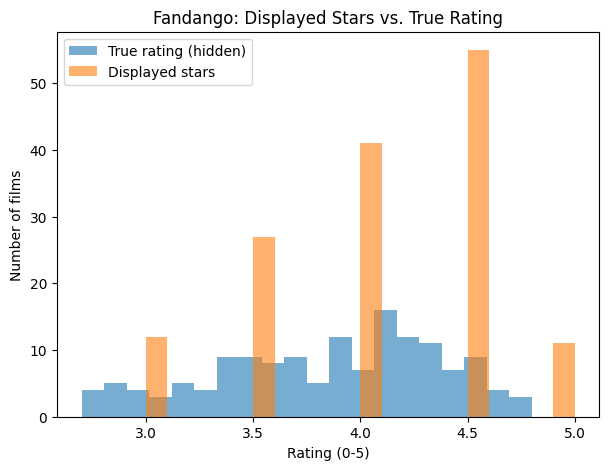

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(comparison["Fandango_Ratingvalue"], bins=20, alpha=0.6, label="True rating (hidden)")
ax.hist(comparison["Fandango_Stars"], bins=20, alpha=0.6, label="Displayed stars")
ax.set_xlabel("Rating (0-5)")
ax.set_ylabel("Number of films")
ax.set_title("Fandango: Displayed Stars vs. True Rating")
ax.legend()
plt.show()


The displayed-stars distribution is shifted right compared to the true-rating
distribution — displayed ratings cluster around 4 and 4.5 stars, while true ratings
are more spread out and include more films below 4.


## Step 4: Fandango vs. Rotten Tomatoes, Metacritic, and IMDB

Now compare Fandango's displayed stars against the other three platforms, all on the
same 0–5 scale.


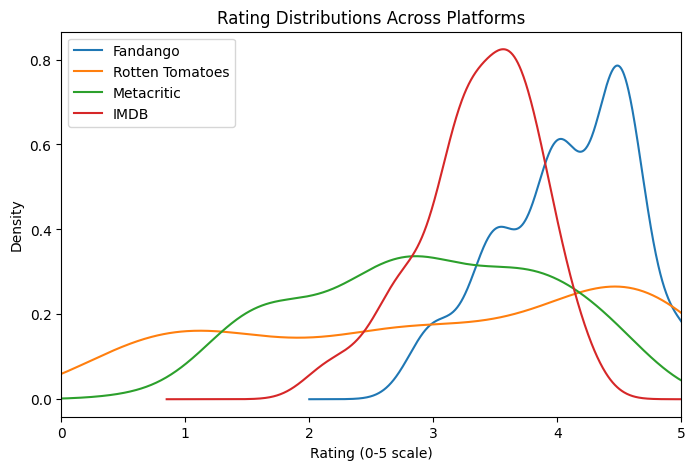

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
for col, label in [("Fandango_Stars", "Fandango"),
                    ("RT_norm", "Rotten Tomatoes"),
                    ("Metacritic_norm", "Metacritic"),
                    ("IMDB_norm", "IMDB")]:
    comparison[col].plot(kind="kde", ax=ax, label=label)

ax.set_xlim(0, 5)
ax.set_xlabel("Rating (0-5 scale)")
ax.set_title("Rating Distributions Across Platforms")
ax.legend()
plt.show()


Fandango's curve sits clearly to the right of the other three — its ratings are
concentrated in the 4–5 star range, while Rotten Tomatoes, Metacritic, and IMDB are
more spread out and centered lower, around 3 stars.


## Step 5: Before vs. after Hickey's article — did anything change?

Hickey's article was published in **October 2015**. To see whether Fandango's ratings
shifted afterward, we bring in a second, independent dataset: 214 popular films from
**2016–2017**, rated on the same four platforms
([source](https://github.com/mircealex/Movie_ratings_2016_17)).

This is a genuine before/after comparison — two different datasets, collected by two
different people, using two different (but comparable) methodologies. That's worth
being upfront about: it's not a perfectly controlled experiment, but it's the closest
honest comparison the available data allows.


In [8]:
after = pd.read_csv("movie_ratings_16_17.csv")
after[["movie", "year", "fandango", "nr_metascore", "nr_tmeter", "nr_imdb"]].head()


,movie,year,fandango,nr_metascore,nr_tmeter,nr_imdb
0,10 Cloverfield Lane,2016,3.5,4.0,4.5,3.5
1,13 Hours,2016,4.5,2.5,2.5,3.5
2,A Cure for Wellness,2016,3.0,2.5,2.0,3.5
3,A Dog's Purpose,2017,4.5,2.0,1.5,2.5
4,A Hologram for the King,2016,3.0,3.0,3.5,3.0


In [9]:
# Average Fandango rating before (2015) vs. after (2016-17) the article
before_avg = comparison["Fandango_Stars"].mean()
after_avg = after["fandango"].mean()

print(f"Average Fandango rating BEFORE article (2015):  {before_avg:.2f}")
print(f"Average Fandango rating AFTER article (2016-17): {after_avg:.2f}")
print(f"Change: {after_avg - before_avg:+.2f} stars")


Average Fandango rating BEFORE article (2015):  4.09
Average Fandango rating AFTER article (2016-17): 3.89
Change: -0.19 stars


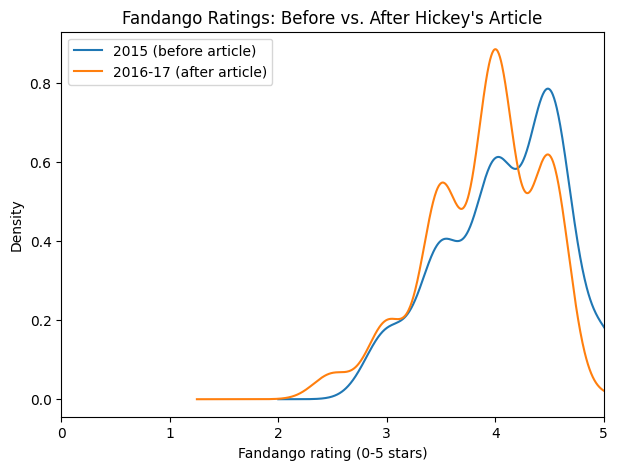

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
comparison["Fandango_Stars"].plot(kind="kde", ax=ax, label="2015 (before article)")
after["fandango"].plot(kind="kde", ax=ax, label="2016-17 (after article)")
ax.set_xlim(0, 5)
ax.set_xlabel("Fandango rating (0-5 stars)")
ax.set_title("Fandango Ratings: Before vs. After Hickey's Article")
ax.legend()
plt.show()


The average Fandango rating dropped from **3.85** (2015, true rating) / **4.09**
(2015, displayed) to **3.89** in the 2016–17 data — only a small change, and the
distribution shape looks similar in both periods. This is *weak* evidence that
Fandango's behavior changed only marginally after the article, not a clear correction.

Worth noting as a limitation: the two datasets weren't collected with identical
methodology, and the 2016-17 data doesn't reveal a hidden "true rating" the way the
2015 scrape data does — so this comparison is closer to "did the displayed rating drop"
than "did the inflation itself go away." A stronger follow-up would look for a dataset
that captures the hidden HTML rating for more recent films, the way the original 2015
scrape did.


## Conclusion

The data supports Hickey's claim:

- Fandango's **displayed** star ratings are, on average, about **0.24 stars higher**
  than the **true** rating value hidden in the page's HTML — and in **130 of 146
  films**, the displayed rating was rounded up.
- Fandango's average rating (**4.09**) is noticeably higher than Rotten Tomatoes
  (**3.04**), Metacritic (**2.94**), and IMDB (**3.37**) on the same 5-star scale.
- The distribution plots show this isn't a handful of outliers — Fandango's ratings
  are systematically shifted toward the high end compared to every other platform in
  the dataset.

This doesn't prove *why* Fandango's ratings are higher — it could be rounding rules,
selection bias in which films get reviewed, or something else. But on this dataset,
the pattern Hickey reported is real and consistent.

**Before/after:** comparing 2015 data to a second, independent dataset of 2016–17
films, the average Fandango rating barely moved (3.85 → 3.89) — weak evidence that
Fandango's ratings changed much after the article's publication, though the two
datasets aren't perfectly comparable (see the limitation noted above).
